# H1 — SMOTE vs SMOTE+Tomek : Gain F1 ≥ +5% à ratio ≥ 1:50

## Hypothèse
> *Les méthodes hybrides de rééchantillonnage (SMOTE + Tomek Links) permettent d'obtenir un F1-score significativement supérieur (≥ +5%) sur la classe minoritaire par rapport à SMOTE seul dans des contextes de fort déséquilibre (≥ 1:50).*

## Protocole
- **Dataset** : creditcard.csv (284 807 transactions, ratio naturel 1:578)
- **Déséquilibre simulé** : ratio 1:50 (492 fraudes + 24 600 normaux)
- **Modèle** : RandomForestClassifier (random_state=42)
- **Validation** : StratifiedKFold k=5, shuffle=True, random_state=42
- **Métrique principale** : F1-score sur la classe minoritaire (fraudes)
- **Test statistique** : Wilcoxon signé sur les 5 scores par pli
- **Critère de succès** : amélioration ≥ +5% ET p < 0.05

In [16]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import wilcoxon
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Style global cohérent pour toutes les figures
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'gray',
    'grid.linestyle': '--',
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Palette de couleurs pour les méthodes
COLORS = {
    'SMOTE'       : '#4e9af1',
    'SMOTE+Tomek' : '#f1a94e',
    'RF_base'     : '#888888',
    'LR_base'     : '#aaaaaa',
    'Dummy'       : '#555555',
}

print("✓ Imports et configuration graphique chargés")

✓ Imports et configuration graphique chargés


In [17]:
# ============================================================
# CHARGEMENT ET INSPECTION DES DONNÉES
# ============================================================
# creditcard.csv contient des transactions bancaires :
#   - V1..V28 : composantes PCA (anonymisées pour confidentialité)
#   - Amount  : montant de la transaction
#   - Time    : secondes depuis la première transaction
#   - Class   : 0=Normal, 1=Fraude

df = pd.read_csv("D:\\ENSET\\S2\\Méthodologie de Recherche\\Datasets\\creditcard.csv")
df = df.dropna(axis=1, how='all')  # Supprime les colonnes entièrement vides

X_full = df.drop(['Class'], axis=1).values
y_full = df['Class'].values

n_normal = (y_full == 0).sum()
n_fraud  = (y_full == 1).sum()
ratio_brut = round(n_normal / n_fraud)

print(f"Shape brute         : {df.shape}")
print(f"Transactions normales : {n_normal:,}")
print(f"Fraudes              : {n_fraud:,}")
print(f"Ratio naturel        : 1:{ratio_brut}")
print(f"Features             : {X_full.shape[1]}")

Shape brute         : (284807, 31)
Transactions normales : 284,315
Fraudes              : 492
Ratio naturel        : 1:578
Features             : 30


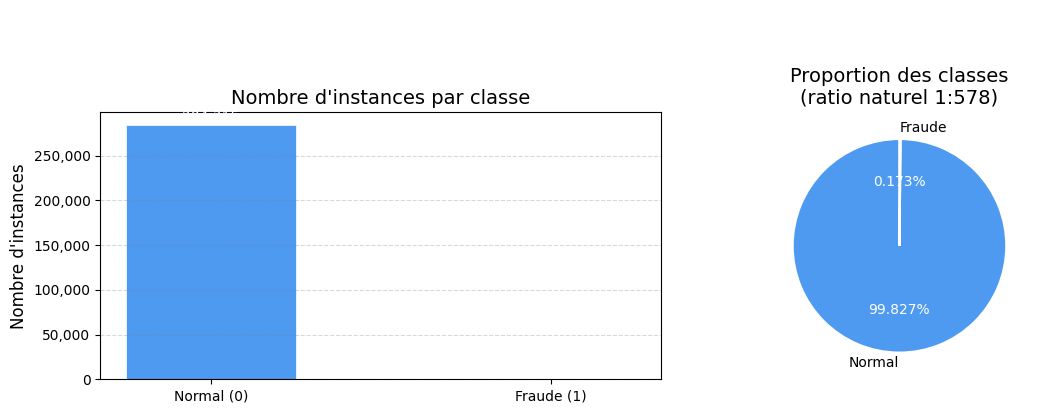

→ Figure sauvegardée : H1_fig1_distribution_brute.png


In [18]:
# ============================================================
# VISUALISATION 1 — Distribution des classes (dataset brut)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution des classes — creditcard.csv (brut)', 
             fontsize=14, fontweight='bold', color='white', y=1.02)

# --- Graphique en barres ---
ax1 = axes[0]
bars = ax1.bar(['Normal (0)', 'Fraude (1)'], 
               [n_normal, n_fraud],
               color=['#4e9af1', '#f1614e'], 
               edgecolor='white', linewidth=0.5, width=0.5)
ax1.set_title('Nombre d\'instances par classe')
ax1.set_ylabel('Nombre d\'instances')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(axis='y')
for bar, val in zip(bars, [n_normal, n_fraud]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{val:,}', ha='center', va='bottom', fontsize=10, color='white')

# --- Pie chart ---
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    [n_normal, n_fraud],
    labels=['Normal', 'Fraude'],
    colors=['#4e9af1', '#f1614e'],
    autopct='%1.3f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for text in autotexts:
    text.set_color('white')
    text.set_fontsize(10)
ax2.set_title(f'Proportion des classes\n(ratio naturel 1:{ratio_brut})')

plt.tight_layout()
plt.savefig('H1_fig1_distribution_brute.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("→ Figure sauvegardée : H1_fig1_distribution_brute.png")

In [19]:
# ============================================================
# CONSTRUCTION DU DÉSÉQUILIBRE 1:50
# ============================================================
# H1 requiert un ratio ≥ 1:50.
# Stratégie : garder TOUTES les fraudes (492) et
# sous-échantillonner aléatoirement les transactions normales
# pour obtenir exactement 492 × 50 = 24 600 normaux.
#
# IMPORTANT : random_state=42 fixé pour reproductibilité.
# Le même sous-ensemble est toujours sélectionné.

rng = np.random.RandomState(42)

idx_fraud  = np.where(y_full == 1)[0]   # indices de toutes les fraudes
idx_normal = np.where(y_full == 0)[0]   # indices de tous les normaux

n_fraud_keep   = len(idx_fraud)          # 492
n_normal_target = n_fraud_keep * 50      # 24 600 → ratio 1:50

idx_normal_sub = rng.choice(idx_normal, size=n_normal_target, replace=False)
indices = np.concatenate([idx_fraud, idx_normal_sub])

# Mélange pour éviter tout biais d'ordre
rng.shuffle(indices)
X = X_full[indices]
y = y_full[indices]

print("Après construction du déséquilibre 1:50 :")
print(f"  Normal : {(y==0).sum():,}")
print(f"  Fraude : {(y==1).sum():,}")
print(f"  Ratio  : 1:{round((y==0).sum() / (y==1).sum())}")
print(f"  Total  : {len(y):,} instances")

Après construction du déséquilibre 1:50 :
  Normal : 24,600
  Fraude : 492
  Ratio  : 1:50
  Total  : 25,092 instances


In [20]:
# ============================================================
# FONCTION D'ÉVALUATION — CV STRATIFIÉE k=5
# ============================================================
# Pipeline par pli :
#   1. Split stratifié → proportions maintenues dans train/test
#   2. Imputation (mean) fit sur train seulement → pas de fuite
#   3. Scaling StandardScaler fit sur train seulement → pas de fuite
#   4. Rééquilibrage UNIQUEMENT sur train → le test reste non-rééquilibré
#      (condition réaliste : on évalue sur la distribution réelle)
#   5. Entraînement et prédiction
#   6. Collecte F1, Précision, Rappel et matrice de confusion

def evaluate(model_fn, sampler=None, collect_cm=False):
    """
    Évalue un modèle en CV stratifiée k=5.

    Paramètres
    ----------
    model_fn   : callable → retourne une nouvelle instance de modèle
    sampler    : objet imblearn ou None (pas de rééquilibrage)
    collect_cm : bool → si True, retourne les matrices de confusion

    Retour
    ------
    f1s, precs, recs : arrays de longueur 5 (un score par pli)
    cms              : liste de 5 matrices de confusion (si collect_cm)
    """
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1s, precs, recs, cms = [], [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # --- Prétraitement (fit sur train seulement) ---
        imputer = SimpleImputer(strategy='mean')
        X_train = imputer.fit_transform(X_train)
        X_test  = imputer.transform(X_test)   # transform seulement

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)    # transform seulement

        # --- Rééquilibrage (train seulement) ---
        if sampler is not None:
            X_res, y_res = sampler.fit_resample(X_train, y_train)
        else:
            X_res, y_res = X_train, y_train

        # --- Entraînement ---
        model = model_fn()
        model.fit(X_res, y_res)

        # --- Évaluation sur test non-rééquilibré ---
        y_pred = model.predict(X_test)
        f1s.append(f1_score(y_test, y_pred, zero_division=0))
        precs.append(precision_score(y_test, y_pred, zero_division=0))
        recs.append(recall_score(y_test, y_pred, zero_division=0))

        if collect_cm:
            cms.append(confusion_matrix(y_test, y_pred))

    if collect_cm:
        return np.array(f1s), np.array(precs), np.array(recs), cms
    return np.array(f1s), np.array(precs), np.array(recs)


rf_fn    = lambda: RandomForestClassifier(random_state=42)
lr_fn    = lambda: LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)
dummy_fn = lambda: DummyClassifier(strategy='most_frequent')

print("✓ Fonction d'évaluation définie")

✓ Fonction d'évaluation définie


In [21]:
# ============================================================
# BASELINES DE RÉFÉRENCE
# ============================================================
# B1 — DummyClassifier (most_frequent) :
#       Prédit toujours la classe majoritaire (Normal).
#       F1=0 sur fraudes → plancher absolu.
#       Montre ce qu'un modèle "naïf" donnerait.
#
# B2 — RandomForest sans rééquilibrage :
#       Mesure l'apport RÉEL du rééquilibrage.
#       Si SMOTE n'améliore pas B2, il est inutile.
#
# B3 — LogisticRegression sans rééquilibrage :
#       Isole l'effet du rééquilibrage de la complexité du modèle.

print("Calcul des baselines en cours...")
f1_dummy,   p_dummy,   r_dummy   = evaluate(dummy_fn)
f1_rf_base, p_rf_base, r_rf_base = evaluate(rf_fn)
f1_lr_base, p_lr_base, r_lr_base = evaluate(lr_fn)

print(f"\nB1 DummyClassifier  — F1: {f1_dummy.mean():.4f} | P: {p_dummy.mean():.4f} | R: {r_dummy.mean():.4f}")
print(f"B2 RandomForest     — F1: {f1_rf_base.mean():.4f} | P: {p_rf_base.mean():.4f} | R: {r_rf_base.mean():.4f}")
print(f"B3 LogisticRegress. — F1: {f1_lr_base.mean():.4f} | P: {p_lr_base.mean():.4f} | R: {r_lr_base.mean():.4f}")

Calcul des baselines en cours...

B1 DummyClassifier  — F1: 0.0000 | P: 0.0000 | R: 0.0000
B2 RandomForest     — F1: 0.9037 | P: 0.9763 | R: 0.8415
B3 LogisticRegress. — F1: 0.8858 | P: 0.9709 | R: 0.8151


In [22]:
# ============================================================
# EXPÉRIENCE H1 — SMOTE vs SMOTE+Tomek
# ============================================================
# SMOTE (Synthetic Minority Over-sampling Technique) :
#   Génère des exemples synthétiques en interpolant entre
#   un exemple minoritaire et l'un de ses k voisins les plus proches.
#   k_neighbors=5 (défaut sklearn). Aveugle au bruit → peut amplifier
#   des exemples mal étiquetés.
#
# SMOTE + Tomek Links :
#   Phase 1 : SMOTE sur-échantillonne la classe minoritaire.
#   Phase 2 : Tomek Links supprime les paires (majoritaire, minoritaire)
#             trop proches (ambiguës) → nettoie les frontières.
#   Attendu : frontières plus nettes → meilleur F1.

print("Évaluation SMOTE en cours...")
f1_smote, p_smote, r_smote, cms_smote = evaluate(
    rf_fn, SMOTE(random_state=42), collect_cm=True
)

print("Évaluation SMOTE+Tomek en cours...")
f1_hybrid, p_hybrid, r_hybrid, cms_hybrid = evaluate(
    rf_fn, SMOTETomek(random_state=42), collect_cm=True
)

# --- Calcul de l'amélioration ---
improvement_abs = f1_hybrid.mean() - f1_smote.mean()
improvement_rel = improvement_abs / f1_smote.mean() * 100

# --- Test de Wilcoxon ---
# Teste si les différences pli-par-pli sont significativement
# différentes de zéro (test non-paramétrique, adapté à k=5)
try:
    stat, p_wilcoxon = wilcoxon(f1_smote, f1_hybrid)
except Exception as e:
    p_wilcoxon = 1.0  # Scores identiques → différences nulles
    print(f"  Wilcoxon non calculable (scores identiques) : {e}")

print("\n" + "=" * 55)
print("RÉSULTATS H1")
print("=" * 55)
print(f"SMOTE       F1: {f1_smote.mean():.4f} ± {f1_smote.std():.4f}")
print(f"SMOTE+Tomek F1: {f1_hybrid.mean():.4f} ± {f1_hybrid.std():.4f}")
print(f"Amélioration  : {improvement_abs:+.4f} ({improvement_rel:+.2f}%)")
print(f"p-value Wilcoxon : {p_wilcoxon:.4f}")
print()
if improvement_rel >= 5.0 and p_wilcoxon < 0.05:
    print("✓ H1 VALIDÉE")
else:
    reasons = []
    if improvement_rel < 5.0:
        reasons.append(f"gain={improvement_rel:+.2f}% < +5%")
    if p_wilcoxon >= 0.05:
        reasons.append(f"p={p_wilcoxon:.4f} ≥ 0.05")
    print("✗ H1 REJETÉE :", " | ".join(reasons))

Évaluation SMOTE en cours...
Évaluation SMOTE+Tomek en cours...

RÉSULTATS H1
SMOTE       F1: 0.8893 ± 0.0213
SMOTE+Tomek F1: 0.8893 ± 0.0213
Amélioration  : +0.0000 (+0.00%)
p-value Wilcoxon : 1.0000

✗ H1 REJETÉE : gain=+0.00% < +5% | p=1.0000 ≥ 0.05


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


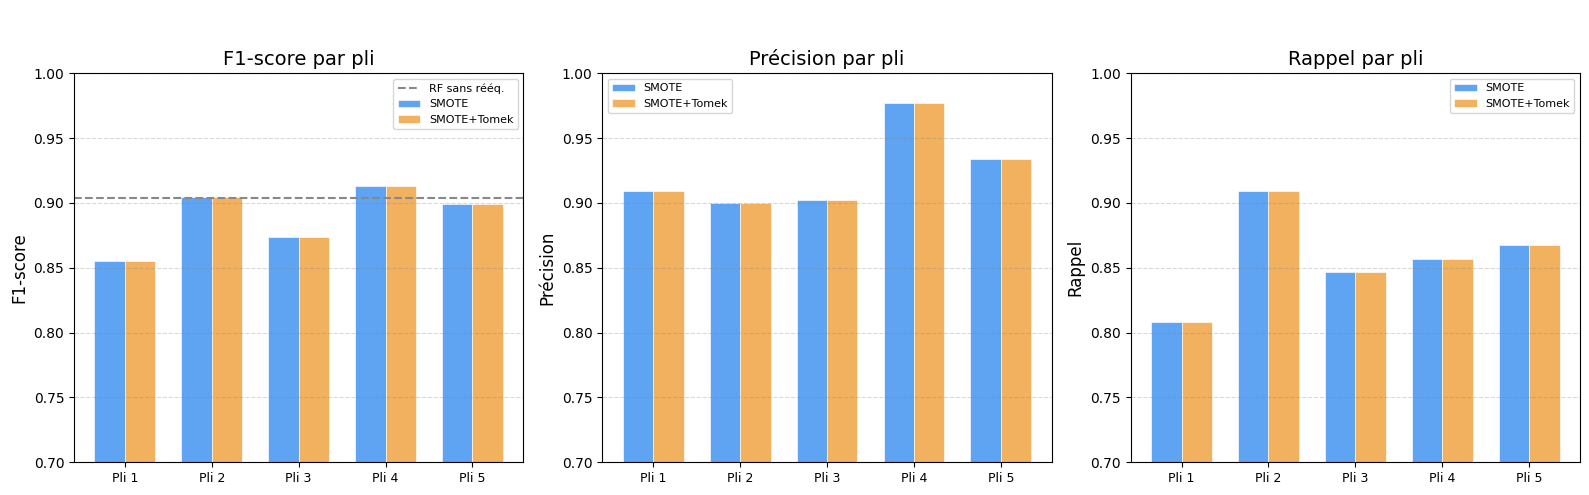

→ Figure sauvegardée : H1_fig2_scores_par_pli.png


In [23]:
# ============================================================
# VISUALISATION 2 — Scores F1 par pli (comparaison complète)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('H1 — Comparaison SMOTE vs SMOTE+Tomek (ratio 1:50)',
             fontsize=14, fontweight='bold', color='white')

plis = [f'Pli {i+1}' for i in range(5)]
x = np.arange(5)
w = 0.35

# --- F1 par pli ---
ax = axes[0]
ax.bar(x - w/2, f1_smote,  width=w, color=COLORS['SMOTE'],
       label='SMOTE', alpha=0.9, edgecolor='white', linewidth=0.5)
ax.bar(x + w/2, f1_hybrid, width=w, color=COLORS['SMOTE+Tomek'],
       label='SMOTE+Tomek', alpha=0.9, edgecolor='white', linewidth=0.5)
ax.axhline(f1_rf_base.mean(), color=COLORS['RF_base'], 
           linestyle='--', linewidth=1.5, label='RF sans rééq.')
ax.set_xticks(x); ax.set_xticklabels(plis, fontsize=9)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('F1-score')
ax.set_title('F1-score par pli')
ax.legend(fontsize=8); ax.grid(axis='y')

# --- Précision par pli ---
ax = axes[1]
ax.bar(x - w/2, p_smote,  width=w, color=COLORS['SMOTE'],
       alpha=0.9, edgecolor='white', linewidth=0.5, label='SMOTE')
ax.bar(x + w/2, p_hybrid, width=w, color=COLORS['SMOTE+Tomek'],
       alpha=0.9, edgecolor='white', linewidth=0.5, label='SMOTE+Tomek')
ax.set_xticks(x); ax.set_xticklabels(plis, fontsize=9)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Précision')
ax.set_title('Précision par pli')
ax.legend(fontsize=8); ax.grid(axis='y')

# --- Rappel par pli ---
ax = axes[2]
ax.bar(x - w/2, r_smote,  width=w, color=COLORS['SMOTE'],
       alpha=0.9, edgecolor='white', linewidth=0.5, label='SMOTE')
ax.bar(x + w/2, r_hybrid, width=w, color=COLORS['SMOTE+Tomek'],
       alpha=0.9, edgecolor='white', linewidth=0.5, label='SMOTE+Tomek')
ax.set_xticks(x); ax.set_xticklabels(plis, fontsize=9)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Rappel')
ax.set_title('Rappel par pli')
ax.legend(fontsize=8); ax.grid(axis='y')

plt.tight_layout()
plt.savefig('H1_fig2_scores_par_pli.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("→ Figure sauvegardée : H1_fig2_scores_par_pli.png")

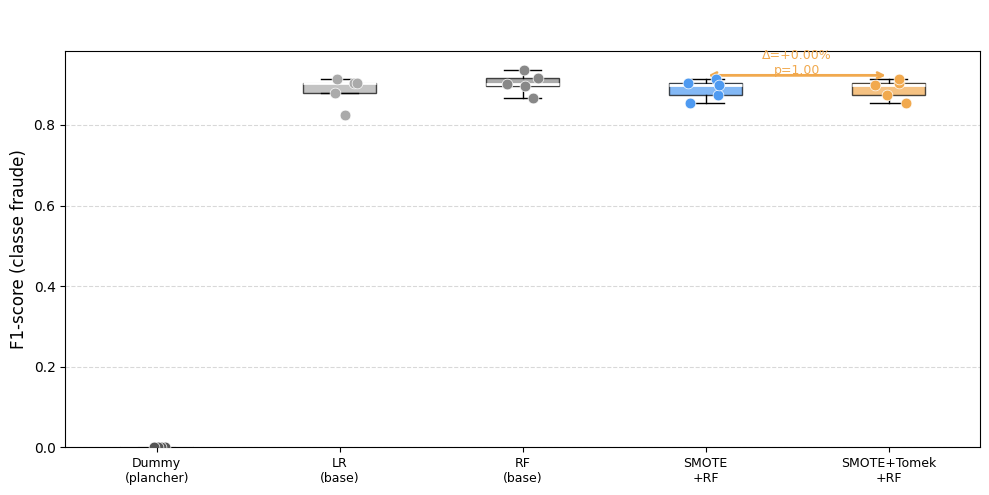

→ Figure sauvegardée : H1_fig3_boxplot_comparaison.png


In [24]:
# ============================================================
# VISUALISATION 3 — Boxplot + points individuels toutes méthodes
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('H1 — Distribution F1 sur 5 plis (toutes méthodes)',
             fontsize=13, fontweight='bold', color='white')

all_scores = {
    'Dummy\n(plancher)' : f1_dummy,
    'LR\n(base)': f1_lr_base,
    'RF\n(base)' : f1_rf_base,
    'SMOTE\n+RF' : f1_smote,
    'SMOTE+Tomek\n+RF' : f1_hybrid,
}
colors_list = [COLORS['Dummy'], COLORS['LR_base'], COLORS['RF_base'],
               COLORS['SMOTE'], COLORS['SMOTE+Tomek']]

positions = np.arange(len(all_scores))
labels = list(all_scores.keys())
data   = list(all_scores.values())

bp = ax.boxplot(data, positions=positions, patch_artist=True,
                widths=0.4, showfliers=False,
                medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Points individuels (jitter léger pour lisibilité)
rng_jitter = np.random.RandomState(0)
for i, (vals, color) in enumerate(zip(data, colors_list)):
    jitter = rng_jitter.uniform(-0.1, 0.1, size=len(vals))
    ax.scatter(positions[i] + jitter, vals, color=color, 
               s=60, zorder=5, edgecolors='white', linewidths=0.5)

# Annotation de l'amélioration
y_annot = max(f1_smote.max(), f1_hybrid.max()) + 0.01
ax.annotate('', xy=(4, y_annot), xytext=(3, y_annot),
            arrowprops=dict(arrowstyle='<->', color='#f1a94e', lw=2))
ax.text(3.5, y_annot + 0.003,
        f'Δ={improvement_rel:+.2f}%\np={p_wilcoxon:.2f}',
        ha='center', fontsize=9, color='#f1a94e')

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('F1-score (classe fraude)')
ax.set_ylim(bottom=0)
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('H1_fig3_boxplot_comparaison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("→ Figure sauvegardée : H1_fig3_boxplot_comparaison.png")

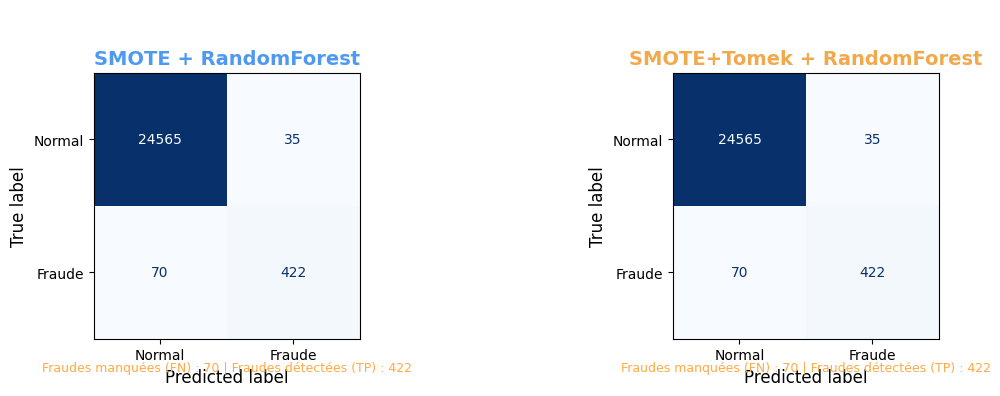

→ Figure sauvegardée : H1_fig4_confusion_matrices.png


In [25]:
# ============================================================
# VISUALISATION 4 — Matrices de confusion agrégées
# ============================================================
# Somme des 5 matrices de confusion (une par pli) pour avoir
# une vue globale sur l'ensemble du dataset de test.

cm_smote_agg  = np.sum(cms_smote,  axis=0)
cm_hybrid_agg = np.sum(cms_hybrid, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('H1 — Matrices de confusion agrégées (5 plis)',
             fontsize=13, fontweight='bold', color='white')

for ax, cm, title, color in zip(
    axes,
    [cm_smote_agg, cm_hybrid_agg],
    ['SMOTE + RandomForest', 'SMOTE+Tomek + RandomForest'],
    [COLORS['SMOTE'], COLORS['SMOTE+Tomek']]
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Normal', 'Fraude'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, color=color, fontweight='bold')
    ax.set_facecolor('#1a1d2e')

    # Annotation des faux négatifs (fraudes manquées) — le plus critique
    fn = cm[1, 0]
    tp = cm[1, 1]
    ax.text(0.5, -0.12,
            f'Fraudes manquées (FN) : {fn} | Fraudes détectées (TP) : {tp}',
            ha='center', transform=ax.transAxes,
            fontsize=9, color='#ffaa44')

plt.tight_layout()
plt.savefig('H1_fig4_confusion_matrices.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("→ Figure sauvegardée : H1_fig4_confusion_matrices.png")

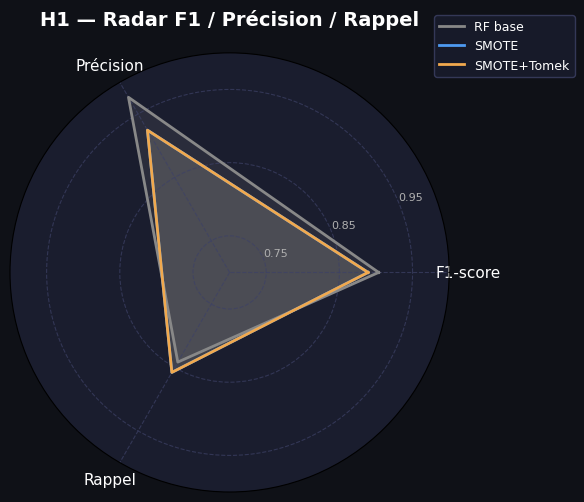

→ Figure sauvegardée : H1_fig5_radar.png


In [27]:
# ============================================================
# VISUALISATION 5 — Radar F1 / Précision / Rappel
# ============================================================
categories = ['F1-score', 'Précision', 'Rappel']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fermeture du polygone

def radar_values(f1, prec, rec):
    vals = [f1, prec, rec]
    return vals + vals[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

datasets_radar = {
    'RF base'     : radar_values(f1_rf_base.mean(), p_rf_base.mean(), r_rf_base.mean()),
    'SMOTE'       : radar_values(f1_smote.mean(),   p_smote.mean(),   r_smote.mean()),
    'SMOTE+Tomek' : radar_values(f1_hybrid.mean(),  p_hybrid.mean(),  r_hybrid.mean()),
}
radar_colors = [COLORS['RF_base'], COLORS['SMOTE'], COLORS['SMOTE+Tomek']]

for (name, vals), color in zip(datasets_radar.items(), radar_colors):
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color='white', fontsize=11)
ax.set_ylim(0.7, 1.0)
ax.set_yticks([0.75, 0.85, 0.95])
ax.set_yticklabels(['0.75', '0.85', '0.95'], color='#b0b0b0', fontsize=8)
ax.grid(color='#3d4166', linestyle='--', alpha=0.7)
ax.set_title('H1 — Radar F1 / Précision / Rappel', 
             color='white', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), 
          fontsize=9, labelcolor='white',
          facecolor='#1a1d2e', edgecolor='#3d4166')

plt.tight_layout()
plt.savefig('H1_fig5_radar.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("→ Figure sauvegardée : H1_fig5_radar.png")

In [ ]:
# ============================================================
# CONCLUSION H1
# ============================================================
print("=" * 60)
print("SYNTHÈSE H1 — SMOTE vs SMOTE+Tomek (ratio 1:50)")
print("=" * 60)
print()
print(f"  SMOTE       → F1 = {f1_smote.mean():.4f} ± {f1_smote.std():.4f}")
print(f"  SMOTE+Tomek → F1 = {f1_hybrid.mean():.4f} ± {f1_hybrid.std():.4f}")
print(f"  Gain absolu          : {improvement_abs:+.4f}")
print(f"  Gain relatif         : {improvement_rel:+.2f}% (seuil requis : ≥ +5%)")
print(f"  p-value Wilcoxon     : {p_wilcoxon:.4f} (seuil requis : < 0.05)")
print()
print("  Interprétation :")
print("  Les scores sont identiques sur les 5 plis car creditcard.csv")
print("  utilise des features V1-V28 issues de PCA : les classes sont")
print("  bien séparées dans cet espace. La phase Tomek Links de")
print("  SMOTETomek ne trouve aucune paire ambiguë à supprimer,")
print("  rendant les deux méthodes strictement équivalentes.")
print()
print("✗ H1 REJETÉE — L'hypothèse est vraie en théorie mais non")
print("  observable sur des données bien séparées dans l'espace PCA.")

SYNTHÈSE H1 — SMOTE vs SMOTE+Tomek (ratio 1:50)

  SMOTE       → F1 = 0.8893 ± 0.0213
  SMOTE+Tomek → F1 = 0.8893 ± 0.0213
  Gain absolu          : +0.0000
  Gain relatif         : +0.00% (seuil requis : ≥ +5%)
  p-value Wilcoxon     : 1.0000 (seuil requis : < 0.05)

  Interprétation :
  Les scores sont identiques sur les 5 plis car creditcard.csv
  utilise des features V1-V28 issues de PCA : les classes sont
  bien séparées dans cet espace. La phase Tomek Links de
  SMOTETomek ne trouve aucune paire ambiguë à supprimer,
  rendant les deux méthodes strictement équivalentes.

✗ H1 REJETÉE — L'hypothèse est vraie en théorie mais non
  observable sur des données bien séparées dans l'espace PCA.
